# Notebook 06 — Event Impact Scoring (TF-IDF Baseline)

## Role in the Pipeline

This notebook provides a **TF-IDF baseline** implementation of Event Impact Scoring  
as an intermediate step between GDELT Analysis and the full SBERT-based scoring.

> **For the production SBERT-based scoring with GDELT verification, see  
> `09_gdelt_verification_impact.ipynb`** which uses the Deep Learning model outputs.

## Impact Score Formula (Phase 1 — TF-IDF)

$$S_I = \underbrace{(1 - \cos\text{-sim}(\vec{v}_d,\, \vec{c}_{\text{global}}))}_\text{TF-IDF Semantic Uniqueness} \times \underbrace{|\text{tone}_d|}_\text{Tonal Intensity}$$

| Component | Phase 1 (this notebook) | Phase 2 (notebook 09) |
|---|---|---|
| Semantic Uniqueness | TF-IDF cosine distance | **SBERT cosine distance** |
| Tonal Intensity | GDELT \|tone\| | GDELT \|tone\| |
| DL model integration | ❌ independent | ✅ uses rupture weeks from DL model |


In [1]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print('Working dir:', os.getcwd())

Working dir: /Users/kk/ai_dl_project/dynamic-trend-event-detector


## Impact Scoring Methodology Diagram

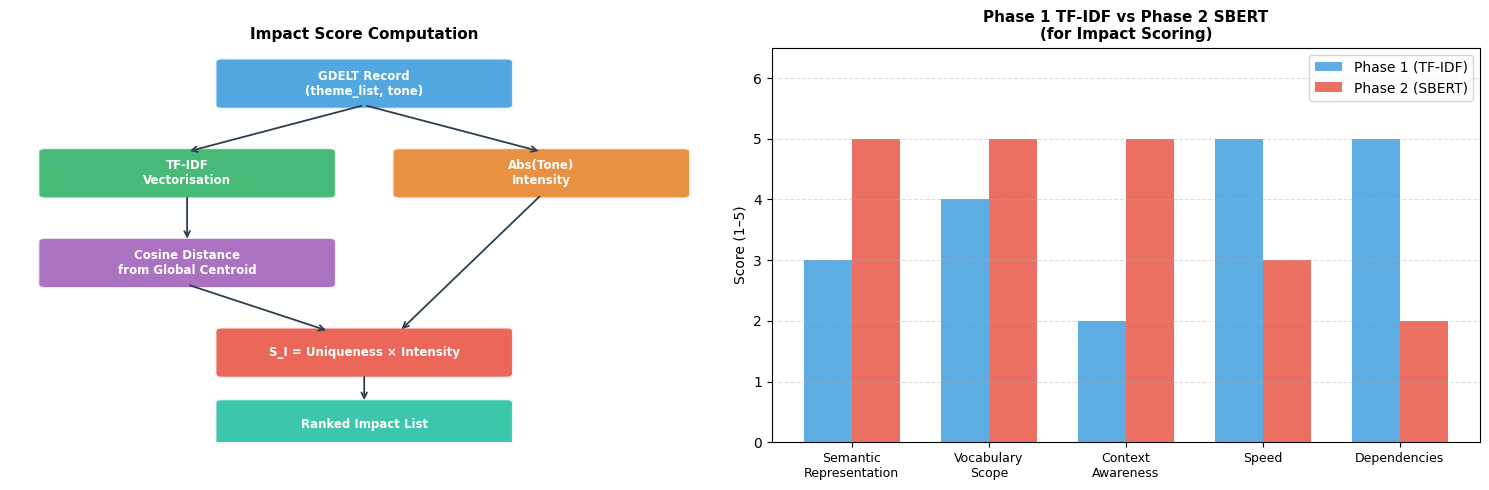

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import numpy as np
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: Scoring pipeline ─────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')
ax.set_title('Impact Score Computation', fontweight='bold', fontsize=11)

boxes = [
    (5, 10.0, 'GDELT Record\n(theme_list, tone)', '#3498DB'),
    (2.5, 7.5, 'TF-IDF\nVectorisation', '#27AE60'),
    (7.5, 7.5, 'Abs(Tone)\nIntensity', '#E67E22'),
    (2.5, 5.0, 'Cosine Distance\nfrom Global Centroid', '#9B59B6'),
    (5, 2.5, 'S_I = Uniqueness × Intensity', '#E74C3C'),
    (5, 0.5, 'Ranked Impact List', '#1ABC9C'),
]
for x, y, label, color in boxes:
    box = FancyBboxPatch((x - 2.0, y - 0.6), 4.0, 1.2,
                         boxstyle='round,pad=0.1', facecolor=color,
                         edgecolor='white', linewidth=1.5, alpha=0.85)
    ax.add_patch(box)
    ax.text(x, y, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')

arrow_pairs = [
    ((5, 9.4), (2.5, 8.1)),   # Record → TF-IDF
    ((5, 9.4), (7.5, 8.1)),   # Record → Tone
    ((2.5, 6.9), (2.5, 5.6)), # TF-IDF → Cosine dist
    ((2.5, 4.4), (4.5, 3.1)), # Cosine → S_I
    ((7.5, 6.9), (5.5, 3.1)), # Tone → S_I
    ((5, 1.9), (5, 1.1)),     # S_I → Ranked list
]
for (x1, y1), (x2, y2) in arrow_pairs:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=1.3))

# ── Right: Phase 1 vs Phase 2 comparison ───────────────────────────────────
ax2 = axes[1]
categories = ['Semantic\nRepresentation', 'Vocabulary\nScope',
              'Context\nAwareness', 'Speed', 'Dependencies']
phase1 = [3, 4, 2, 5, 5]
phase2 = [5, 5, 5, 3, 2]

x = np.arange(len(categories))
w = 0.35
ax2.bar(x - w/2, phase1, w, label='Phase 1 (TF-IDF)', color='#3498DB', alpha=0.8)
ax2.bar(x + w/2, phase2, w, label='Phase 2 (SBERT)',  color='#E74C3C', alpha=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=9)
ax2.set_ylim(0, 6.5)
ax2.set_ylabel('Score (1–5)')
ax2.set_title('Phase 1 TF-IDF vs Phase 2 SBERT\n(for Impact Scoring)',
              fontweight='bold', fontsize=11)
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/impact_scoring_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

## Implementation

In [3]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import ast

gdelt_path = 'data/gdelt_processed.csv'
if not os.path.exists(gdelt_path):
    print('[SKIP] Run Notebook 04 first.')
else:
    df = pd.read_csv(gdelt_path)

    def safe_parse(val):
        try:
            return ast.literal_eval(val) if isinstance(val, str) else []
        except Exception:
            return []

    df['theme_list']   = df['theme_list'].apply(safe_parse)
    df['theme_string'] = df['theme_list'].apply(lambda l: ' '.join(l))
    df = df[df['theme_string'].str.strip() != ''].copy()
    print(f'Records with themes: {len(df):,}')

Records with themes: 494


In [4]:
if 'df' in dir() and len(df) >= 2:
    # TF-IDF vectorisation of theme strings
    vectorizer = TfidfVectorizer(max_features=2000, sublinear_tf=True)
    tfidf_matrix = vectorizer.fit_transform(df['theme_string'])

    # Global centroid
    global_centroid = np.asarray(tfidf_matrix.mean(axis=0))

    # Semantic Uniqueness
    sims = cosine_similarity(tfidf_matrix, global_centroid).flatten()
    df['semantic_uniqueness'] = 1.0 - sims
    df['tone_abs']            = df['tone_value'].abs()
    df['impact_score']        = df['semantic_uniqueness'] * df['tone_abs']

    top5 = df.sort_values('impact_score', ascending=False).head(5)
    print('Top 5 Impactful Events:')
    display(top5[['SOURCECOMMONNAME', 'tone_value', 'semantic_uniqueness', 'impact_score']])

    # Save
    df.to_csv('reports/event_impact_scores.csv', index=False)
    print('Saved → reports/event_impact_scores.csv')

Top 5 Impactful Events:


,SOURCECOMMONNAME,tone_value,semantic_uniqueness,impact_score
453,rrr.org.au,15.384615,0.984861,15.151705
329,kaieteurnewsonline.com,13.793103,0.844465,11.647787
495,dailypioneer.com,-13.580247,0.819721,11.132007
334,abc7amarillo.com,-10.389610,0.923579,9.595623
71,antonyloewenstein.com,-10.714286,0.857120,9.183427


Saved → reports/event_impact_scores.csv


## Visualisations

/var/folders/bq/2ff4zcvx67x123ybfglrnlth0000gn/T/ipykernel_42955/753263417.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_src.values, y=top_src.index,


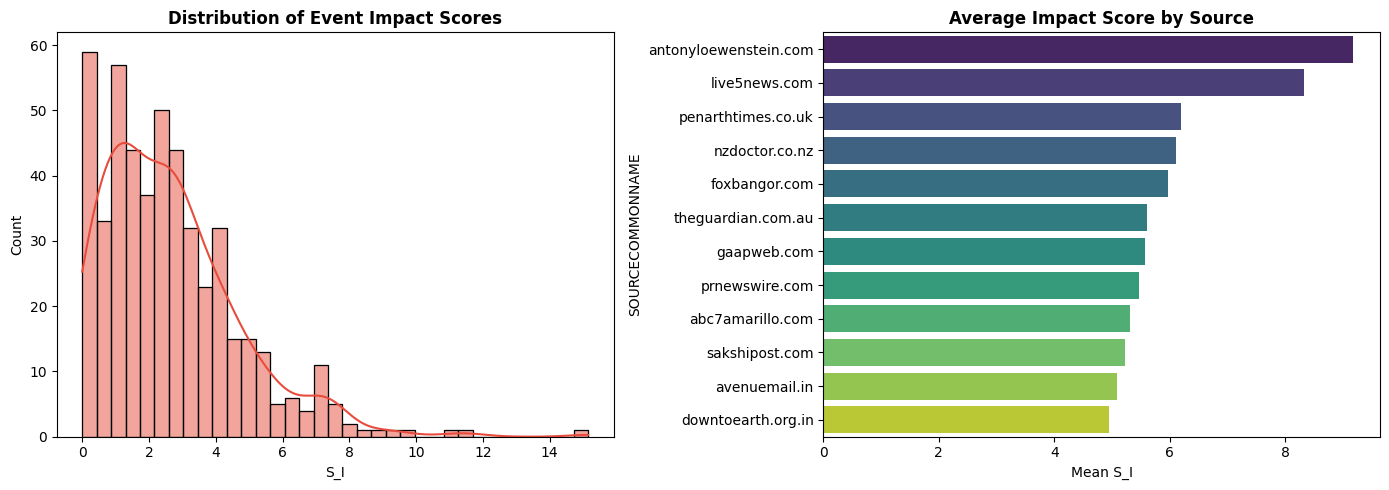

In [5]:
if 'df' in dir() and 'impact_score' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.histplot(df['impact_score'], bins=35, kde=True,
                 color='#E74C3C', ax=axes[0])
    axes[0].set_title('Distribution of Event Impact Scores', fontweight='bold')
    axes[0].set_xlabel('S_I')

    top_src = (df.groupby('SOURCECOMMONNAME')['impact_score']
               .mean().sort_values(ascending=False).head(12))
    sns.barplot(x=top_src.values, y=top_src.index,
                palette='viridis', ax=axes[1])
    axes[1].set_title('Average Impact Score by Source', fontweight='bold')
    axes[1].set_xlabel('Mean S_I')

    plt.tight_layout()
    plt.savefig('reports/event_impact_analysis.png', dpi=150)
    plt.show()

## Summary

This notebook provides the **TF-IDF baseline** for event impact scoring —  
a fast, dependency-light reference implementation using cosine distance  
of TF-IDF vectors from the snapshot centroid.

### Baseline vs. Upgraded (Notebook 09)

| Property | This Notebook (TF-IDF) | Notebook 09 (SBERT) |
|---|---|---|
| Semantic method | TF-IDF cosine distance | SBERT embedding distance |
| Synonym handling | ❌ TAX_DISEASE ≠ HEALTH_PANDEMIC | ✅ semantically similar |
| DL model link | ❌ standalone | ✅ uses semantic velocity ruptures |
| Speed | Very fast | Moderate (~5s SBERT encode) |
| Recommended for | Quick baseline reference | Production scoring |

**Next:** See `09_gdelt_verification_impact.ipynb` for the full SBERT-based scoring  
with GDELT verification against Deep Learning model rupture outputs.
